
<a href="https://www.pieriandata.com"><img src="data/Logo.jpg"></a>
# Opening Image Files in a Notebook

In [2]:
!pip install opencv-python

In [12]:
!pip install sympy

In [15]:
import numpy as np
from sympy import Matrix
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

#### WARNING! Make sure to provide the correct path like we do in our notebooks! ALWAYS confirm that your file path is correct before posting a question on this.

In [16]:
# WONT GIVE ERROR! GIVES NONE INSTEAD!!!
img = cv2.imread("some/wrong/path.jpg")

[ WARN:0@636.083] global loadsave.cpp:278 findDecoder imread_('some/wrong/path.jpg'): can't open/read file: check file path/integrity


`cv2.imread()` with wrong path won't issue any error in default. Instead, it will show `None`.

In [17]:
# UH OH!!
print(img)

None


**NOTE**:  
- `cv2.imread()` gives numpy array directly. 
- `cv2.imread()` reads the image in BGR (reversed) order.

In [19]:
img_bgr = cv2.imread('data/00-puppy.jpg')
print(img_bgr)

[[[78 81 95]
  [80 83 97]
  [81 84 98]
  ...
  [22 27 25]
  [22 27 25]
  [22 27 25]]

 [[78 81 95]
  [79 82 96]
  [79 82 96]
  ...
  [22 27 25]
  [22 27 25]
  [22 27 25]]

 [[78 81 95]
  [77 80 94]
  [77 80 94]
  ...
  [22 27 25]
  [22 27 25]
  [22 27 25]]

 ...

 [[20 29 19]
  [21 30 20]
  [21 30 20]
  ...
  [22 30 23]
  [23 31 24]
  [23 31 24]]

 [[21 30 20]
  [21 30 20]
  [20 29 19]
  ...
  [22 30 23]
  [23 31 24]
  [23 31 24]]

 [[21 30 20]
  [20 29 19]
  [20 29 19]
  ...
  [22 30 23]
  [23 31 24]
  [23 31 24]]]


------------

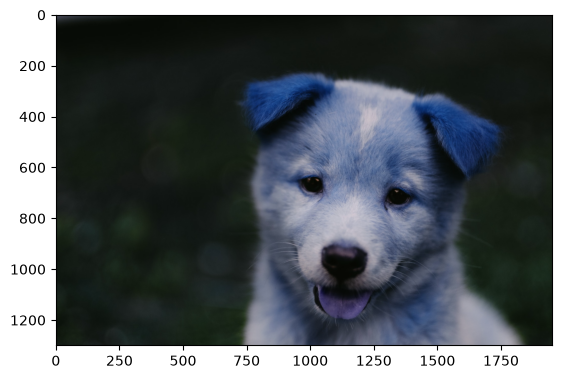

In [21]:
# Read image as BGR in default
img_bgr = cv2.imread('data/00-puppy.jpg')
plt.imshow(img_bgr)

The image has been correctly loaded by openCV as a numpy array, but the color of each pixel has been sorted as BGR.
Matplotlib's plot expects an RGB image so, for a correct display of the image, it is necessary to swap those channels. 
This operation can be done either by using openCV conversion functions cv2.cvtColor() or by working directly with the numpy array.

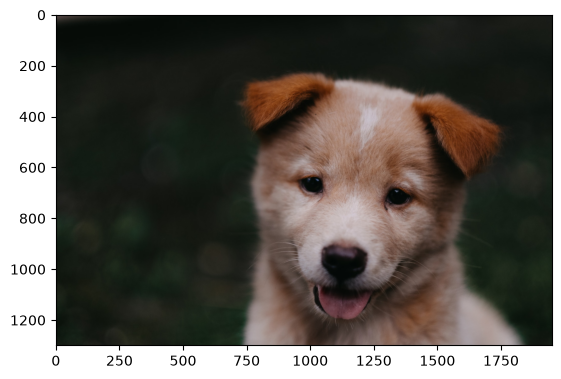

In [25]:
# Convert image as RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

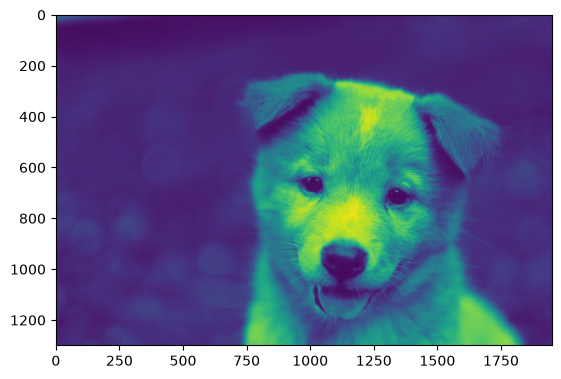

In [26]:
# Read image with grayscale
img_gray = cv2.imread('data/00-puppy.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img_gray)

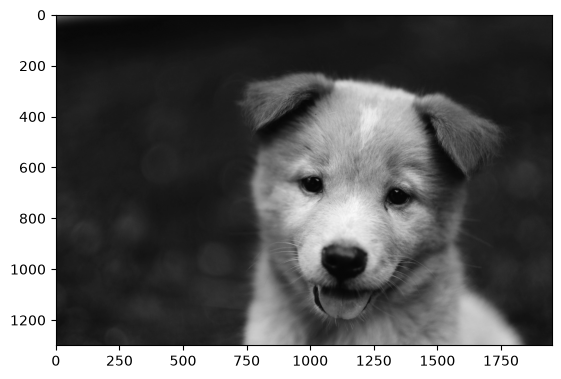

In [27]:
plt.imshow(img_gray, cmap='gray')

## Resize Images by shape

In [28]:
img_rgb.shape
# width, height, color channels

(1300, 1950, 3)

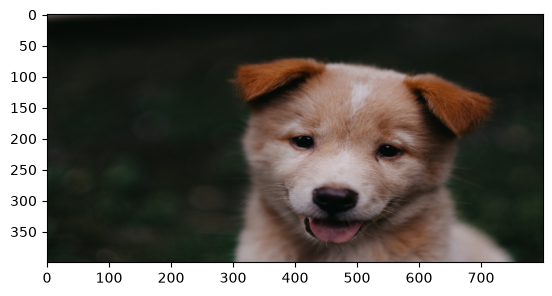

In [36]:
img_resize = cv2.resize(img_rgb, (800, 400))
plt.imshow(img_resize)

## Resize Images by ratio

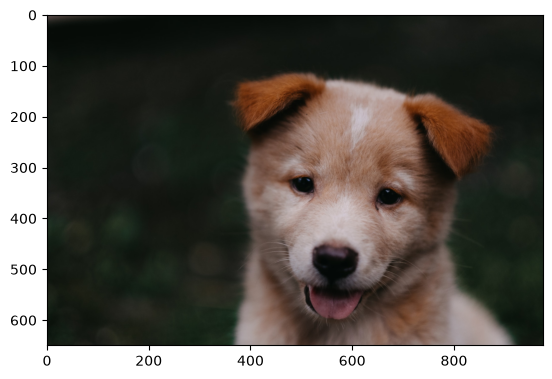

In [42]:
w_ratio = 0.5 # width ratio
h_ratio = 0.5 # height ratio

new_img = cv2.resize(img_rgb, (0,0), img, w_ratio, h_ratio)
plt.imshow(new_img)

**NOTE**:  
```python
cv2.resize(src, dsize, fx, fy)
```  

When you use scaling factors fx and fy, OpenCV calculates the new dimensions automatically. Don't specify the final dimension `dsize = (0,0)`.

### Flipping Images

In [40]:
%matplotlib inline

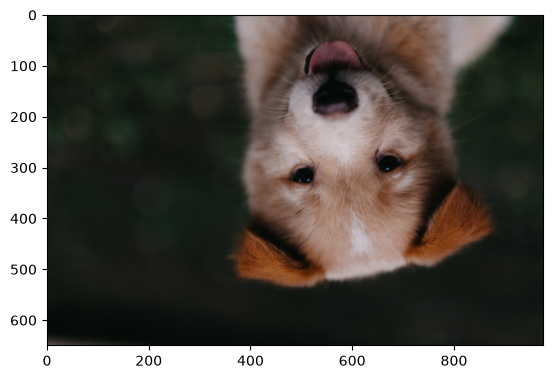

In [43]:
# Along central X-axis
plt.imshow(cv2.flip(new_img, 0))

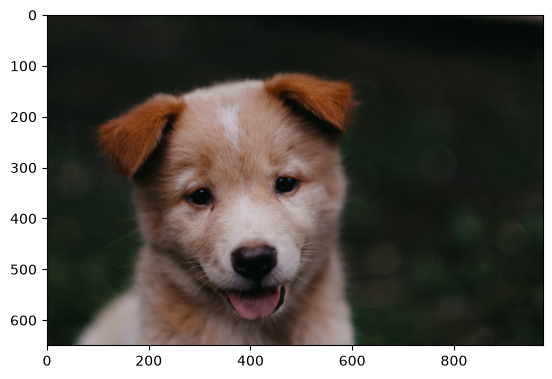

In [44]:
# Along central Y-axis
plt.imshow(cv2.flip(new_img, 1))

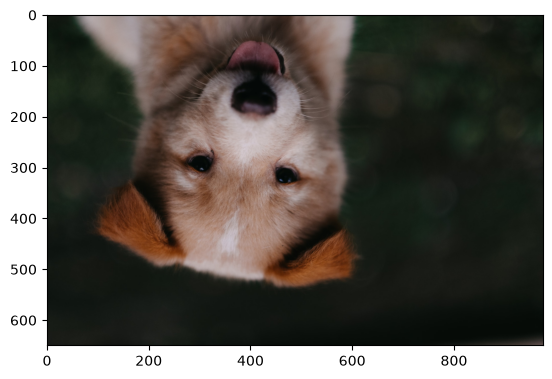

In [45]:
# Along both axes
plt.imshow(cv2.flip(new_img, -1))

--------

# Saving Image Files

In [46]:
type(new_img)

numpy.ndarray

In [47]:
cv2.imwrite('my_new_picture.jpg', new_img)

True

Keep in mind, the above stored the BGR version of the image.

## Larger Displays in the Notebook

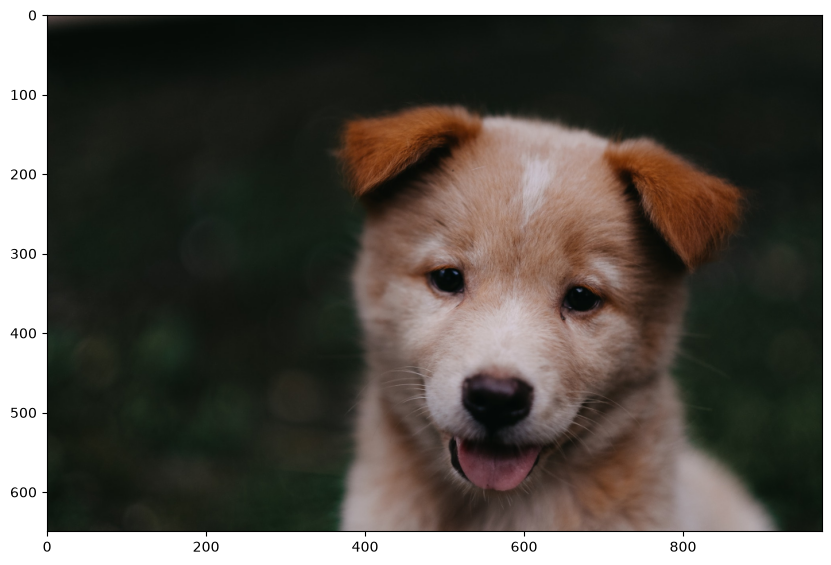

In [48]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
ax.imshow(new_img)